In [14]:
from constraints import get_experiment_folder, get_data_folder, show_torch_image, show_torch_mask
from constraints.datatools.datasets import CachedArtificalDataset, artificial_mask_to_label_map
from pathlib import Path
from constraints.losses_metrics import does_violation_occur_with_wall

import torch
import pytorch_lightning as pl
FOLDER = get_experiment_folder(Path("ex4")/"affine_def")


In [15]:
DATA =get_data_folder() / "artificial" /  "affine_deformed"/"trn"
ds = CachedArtificalDataset(DATA, return_template_sdf=True)

FileNotFoundError: [Errno 2] No such file or directory: '/home/michal/Documents/Skola/diplomka/ctu-constraints/data/artificial/affine_deformed/trn/img.npy'

torch.Size([1, 256, 256]) torch.Size([4, 256, 256]) torch.Size([4, 256, 256])


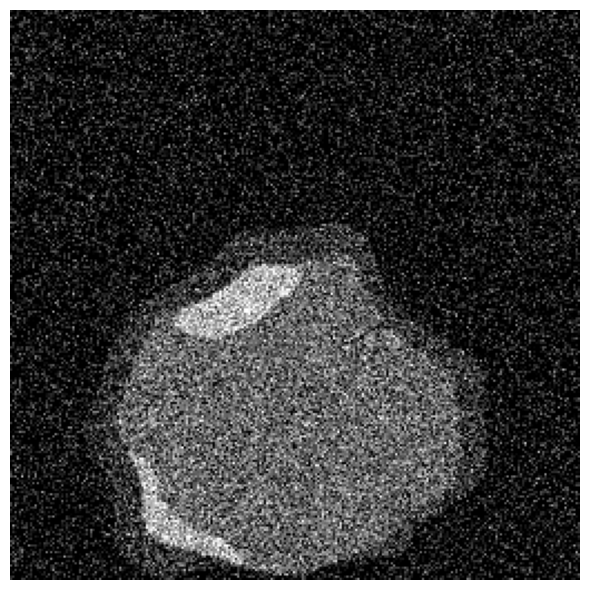

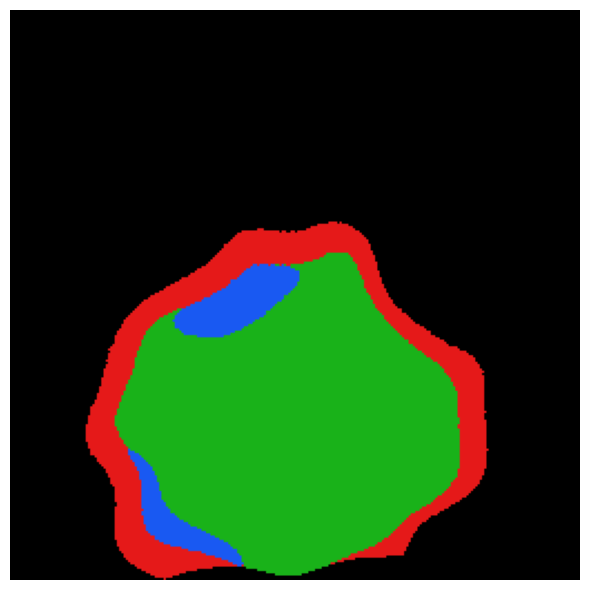

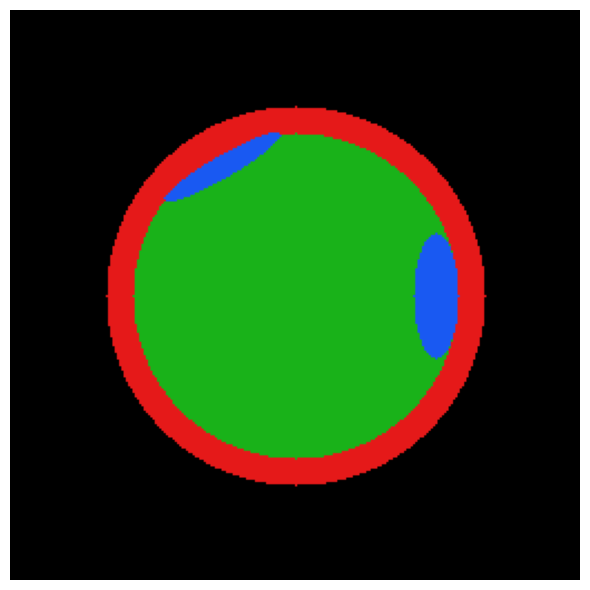

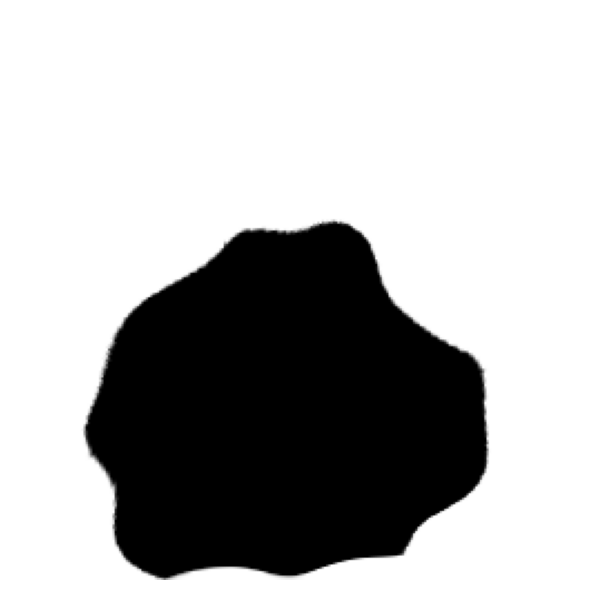

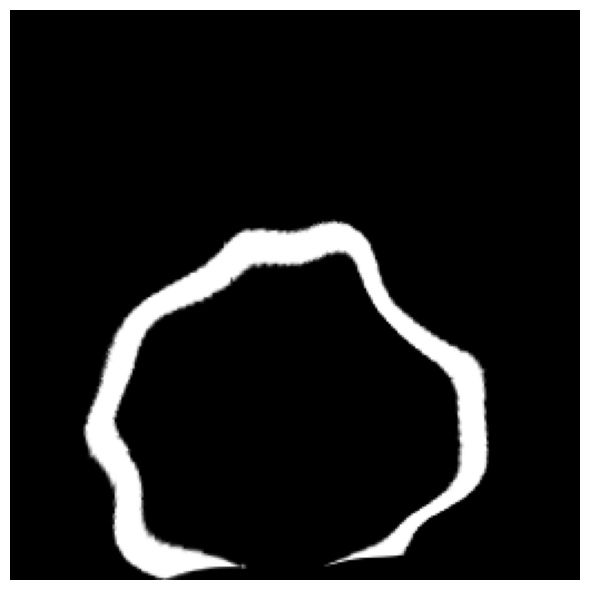

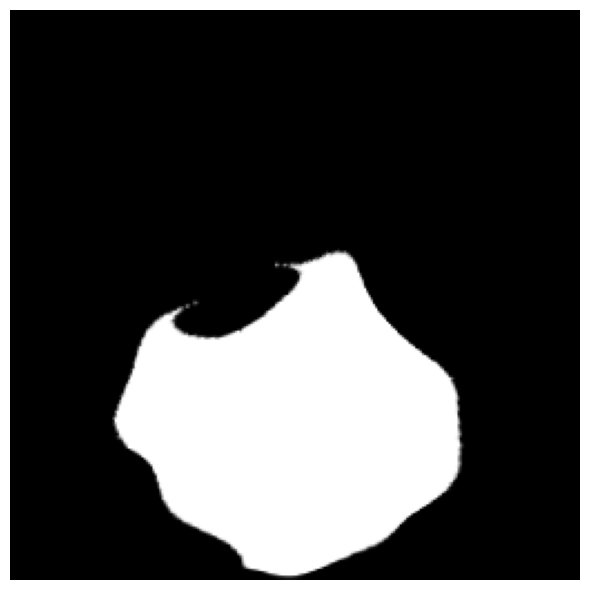

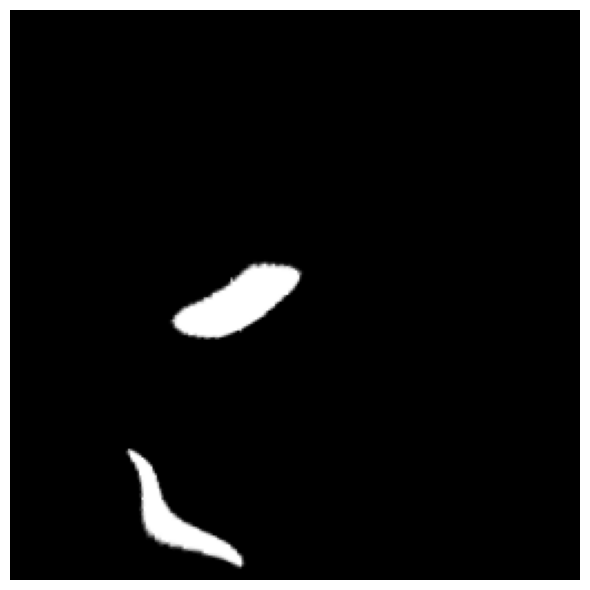

In [ ]:
el = ds[0]
print(el["image"].shape, el["mask"].shape, el["template"].shape)
show_torch_image(el["image"],cmap="gray")
show_torch_mask(el["mask"])
show_torch_mask(el["template"])
show_torch_image(el["mask"][0],cmap="gray")
show_torch_image(el["mask"][1],cmap="gray")
show_torch_image(el["mask"][2],cmap="gray")
show_torch_image(el["mask"][3],cmap="gray")

torch.Size([3, 256, 256])


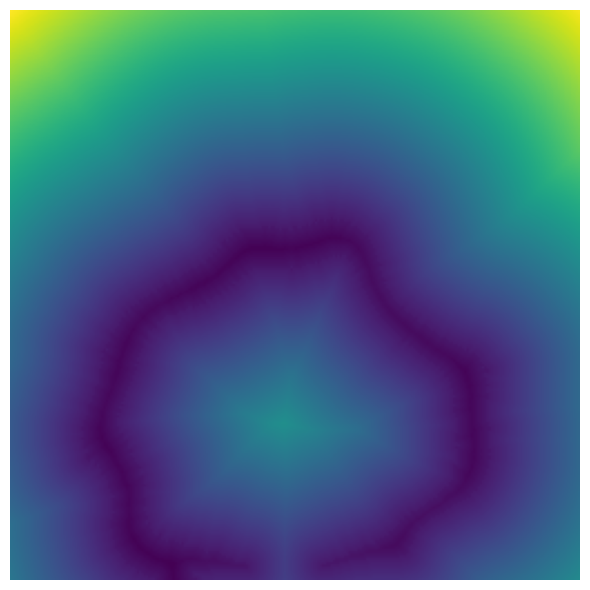

/tmp/ipykernel_154380/1422077426.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  show_torch_image(np.logical_and(sdf[i] > -5, sdf[i] < 5))


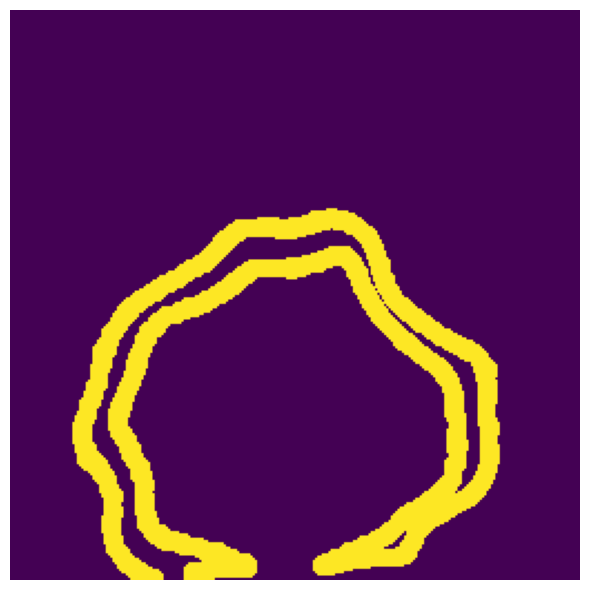

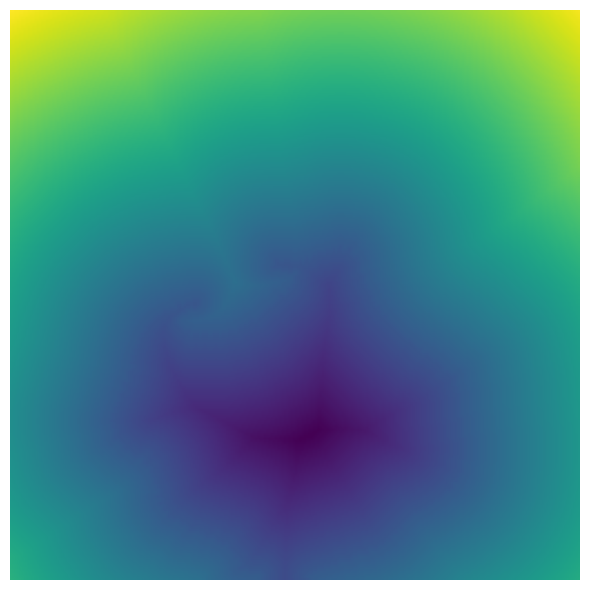

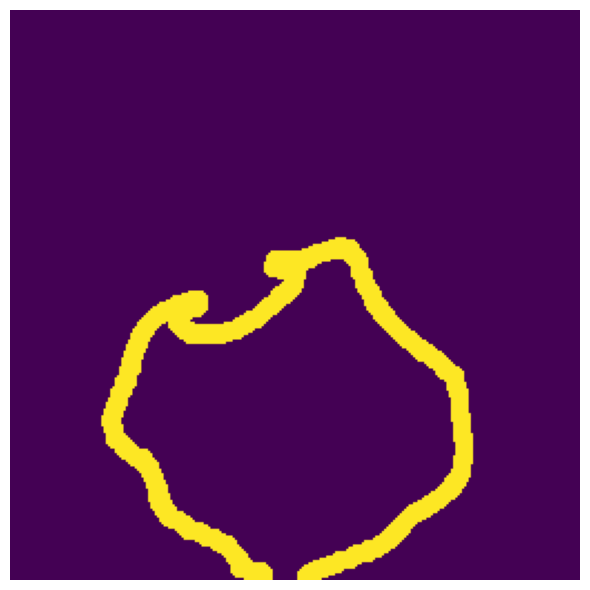

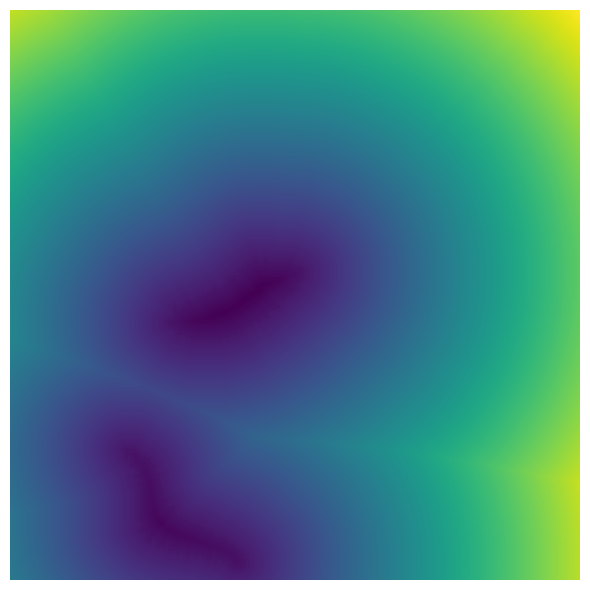

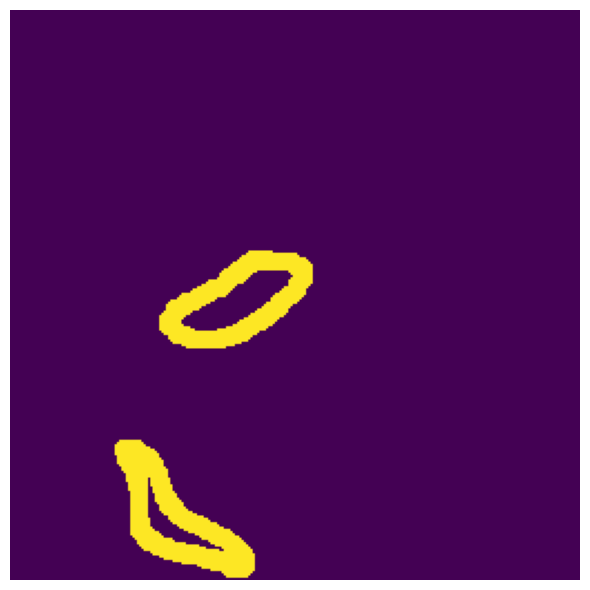

In [ ]:

sdf = el['sdf']
import numpy as np
print(sdf.shape)
for i in range(sdf.size(0)):
    show_torch_image(sdf[i])
    show_torch_image(np.logical_and(sdf[i] > -5, sdf[i] < 5))

torch.Size([3, 256, 256])


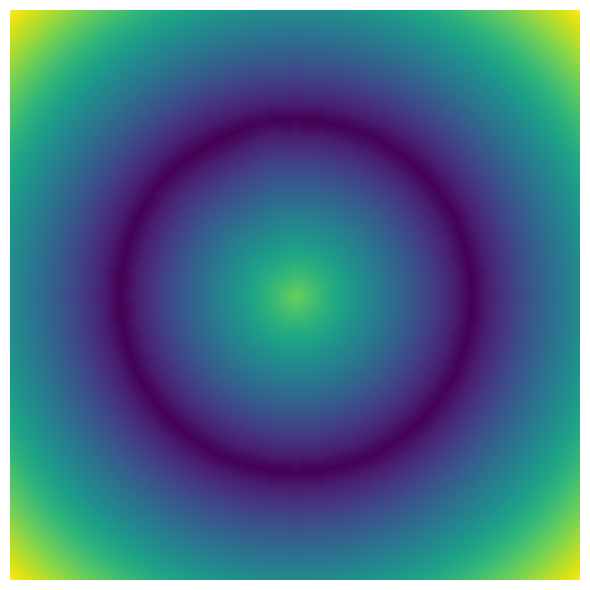

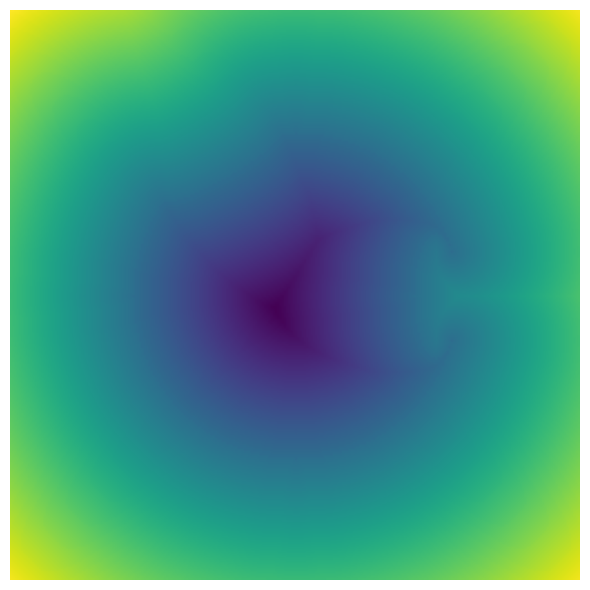

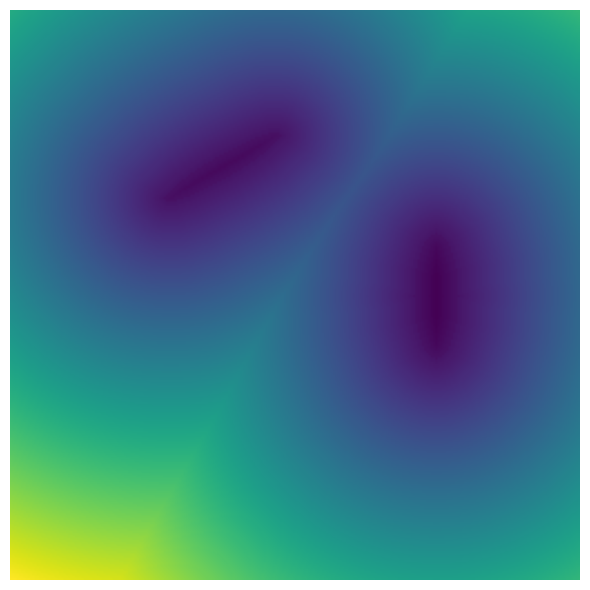

In [ ]:
assert el['template_sdf'] is not None, "template_sdf is None, but return_template_sdf was set to True"
t_sdf = el['template_sdf']
print(t_sdf.shape)
for i in range(t_sdf.size(0)):
    show_torch_image(t_sdf[i])

In [ ]:
el['mask'].shape

torch.Size([4, 256, 256])

In [ ]:
from constraints.datatools.datasets import write_bad_indices

# bad_indices = write_bad_indices(DATA, check_wall_integrity=False)
# print(f"Saved {len(bad_indices)} invalid indices to {DATA / 'bad_indices.csv'}")
# ds = CachedArtificalDataset(DATA, return_template_sdf=True)

Saved 58 invalid indices to /mnt/personal/mrkosmic/synced/constraints/data/artificial/affine_deformed/trn/bad_indices.csv


# Check datasets for correctness

In [ ]:
from constraints.losses_metrics.constraint_function import does_violation_occur_with_wall
print(len(ds))

1942


In [ ]:
for i in range(len(ds)):
    el = ds[i]
    b,info = does_violation_occur_with_wall(artificial_mask_to_label_map(el['mask']),check_wall_integrity=False)
    if b:
        print(f"Violation occurs in sample {i}")
        print(f"Info: {info}")

# Test affine_def

In [1]:
from constraints import get_experiment_folder, get_data_folder, show_torch_image, show_torch_mask
from constraints.datatools.datasets import CachedArtificalDataset, artificial_mask_to_label_map
from pathlib import Path
from constraints.losses_metrics import does_violation_occur_with_wall
from constraints.models.helpers import MomentsAffineAlignment
from constraints.transforms.transformers import RigidTransformer
import torch
import pytorch_lightning as pl
from constraints.types import RigidParams, TransformSpec
FOLDER = get_experiment_folder(Path("ex4")/"affine_def")

In [2]:
DATA =get_data_folder() / "artificial" /  "downloaded"/"affine"/ "trn"
ds = CachedArtificalDataset(DATA, return_template_sdf=True)

In [11]:
el = ds[0]
mom_aff = MomentsAffineAlignment()
transformer = RigidTransformer()

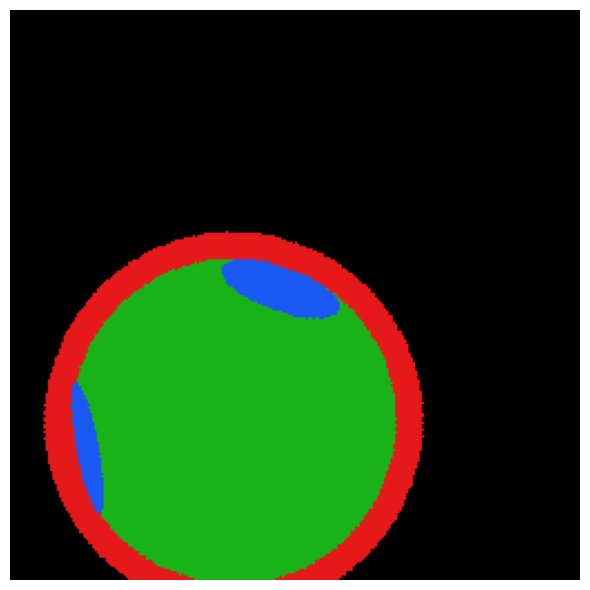

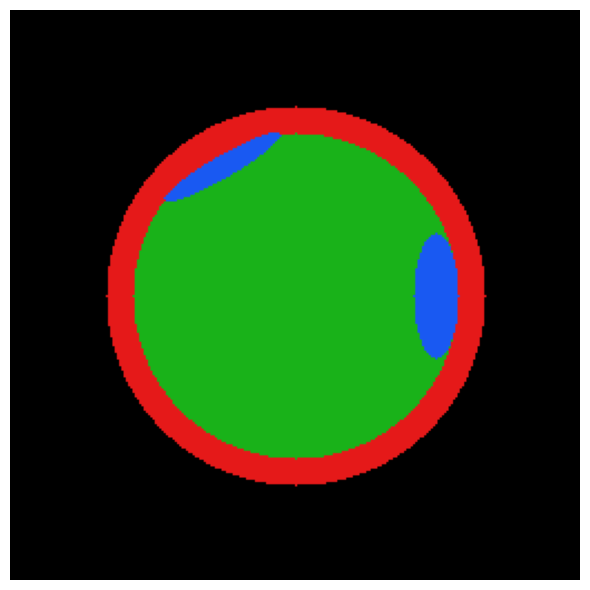

In [12]:
show_torch_mask(el['mask'])
show_torch_mask(el['template'])

In [13]:
res = mom_aff.forward(el['mask'].unsqueeze(0), el['template'])
transform_spec = TransformSpec(rigid=RigidParams(angle=res[0], dx=res[1], dy=res[2]))
print(f"Rigid params: angle={res[0].item()}, dx={res[1].item()}, dy={res[2].item()}")

transformed_mask = transformer.forward(el['template'], transform_spec)

Rigid params: angle=1.2710798978805542, dx=0.4577559232711792, dy=0.08556538820266724


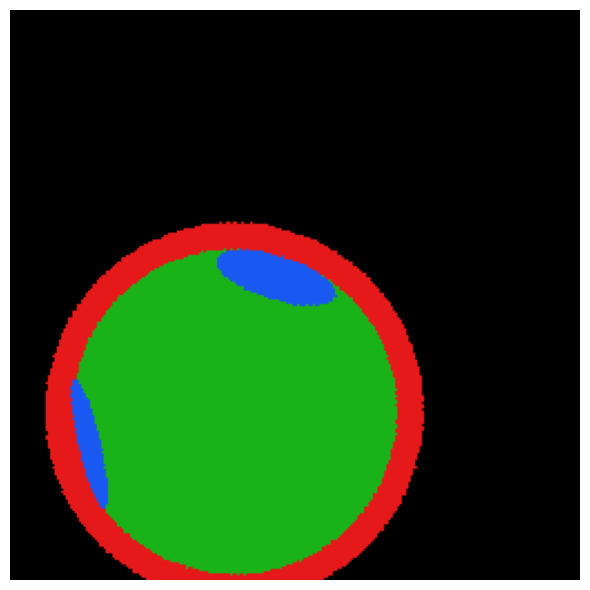

In [14]:
show_torch_mask(transformed_mask.warped_template)

mask shape: torch.Size([4, 256, 256])
template shape: torch.Size([4, 256, 256])
mask min/max: 0.0 1.0
template min/max: 0.0 1.0
centroids source (B,C,2): torch.Size([1, 3, 2])
centroids template (B,C,2): torch.Size([1, 3, 2])
centroids source: tensor([[[ 99.6810, 171.9943],
         [100.8565, 186.9980],
         [ 90.6029, 149.7219]]])
centroids template: tensor([[[127.8713, 127.8294],
         [125.4958, 129.8358],
         [157.3498, 107.6697]]])
mean_src: tensor([[ 97.0468, 169.5714]])
mean_tmpl: tensor([[136.9056, 121.7783]])
warped_template shape: torch.Size([4, 256, 256])
warped_template min/max: 0.0 1.0
warped_template sum: 47643.37109375
template sum: 65536.0


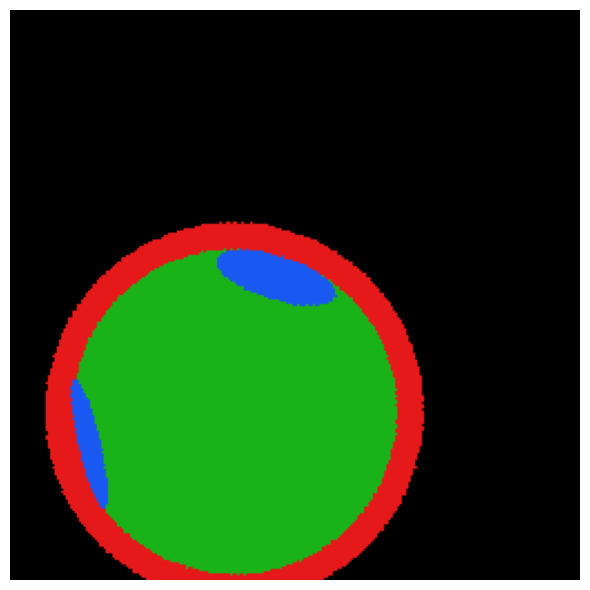

In [15]:
# DIAGNOSTICS
import torch
print("mask shape:", el['mask'].shape)
print("template shape:", el['template'].shape)
print("mask min/max:", el['mask'].min().item(), el['mask'].max().item())
print("template min/max:", el['template'].min().item(), el['template'].max().item())

# centroids (need 4D input)
cs = mom_aff.get_centroids(el['mask'].unsqueeze(0))
ct = mom_aff.get_centroids(el['template'].unsqueeze(0))
print("centroids source (B,C,2):", cs.shape)
print("centroids template (B,C,2):", ct.shape)
print("centroids source:", cs)
print("centroids template:", ct)

# raw Kabsch internals
src = el['mask'].unsqueeze(0)
tmpl = el['template'].unsqueeze(0).expand(src.shape[0], -1, -1, -1)
cs2 = mom_aff.get_centroids(src)
ct2 = mom_aff.get_centroids(tmpl)
mean_src = cs2.mean(dim=1)
mean_tmpl = ct2.mean(dim=1)
print("mean_src:", mean_src)
print("mean_tmpl:", mean_tmpl)

# Check the warped output values
wt = transformed_mask.warped_template
print("warped_template shape:", wt.shape)
print("warped_template min/max:", wt.min().item(), wt.max().item())
print("warped_template sum:", wt.sum().item())
print("template sum:", el['template'].sum().item())

# Show the warped template
show_torch_mask(wt)
